# UPI Transactions Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on a synthetic UPI transaction dataset.

All visualizations use a green theme and are designed for research reporting.

Steps:
1. Load dataset
2. Dataset overview
3. Transaction status distribution
4. Transaction amount distribution
5. Transactions by hour
6. Failure rate by hour
7. Sender bank distribution
8. Receiver bank distribution
9. Transaction amount vs status
10. Correlation heatmap


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')

In [5]:
os.makedirs('../plots', exist_ok=True)

## Load Dataset

In [6]:
df = pd.read_csv('../data/transactions.csv')
df.head()

,Transaction ID,Timestamp,Sender Name,Sender UPI ID,Receiver Name,Receiver UPI ID,Amount (INR),Status
0,4d3db980-46cd-4158-a812-dcb77055d0d2,2024-06-22 04:06:38,Tiya Mall,4161803452@okaxis,Mohanlal Golla,7776849307@okybl,3907.34,FAILED
1,099ee548-2fc1-4811-bf92-559c467ca792,2024-06-19 06:04:49,Mohanlal Bakshi,8908837379@okaxis,Mehul Sankaran,7683454560@okaxis,8404.55,SUCCESS
2,d4c05732-6b1b-4bab-90b9-efe09d252b99,2024-06-04 04:56:09,Kismat Bora,4633654150@okybl,Diya Goel,2598130823@okicici,941.88,SUCCESS
3,e8df92ee-8b04-4133-af5a-5f412180c8ab,2024-06-09 09:56:07,Ayesha Korpal,7018842771@okhdfcbank,Rhea Kothari,2246623650@okaxis,8926.00,SUCCESS
4,e7d675d3-04f1-419c-a841-7a04662560b7,2024-06-25 08:38:19,Jivin Batta,1977143985@okybl,Baiju Issac,5245672729@okybl,2800.55,SUCCESS


## Dataset Overview

In [7]:
print('Dataset Shape:', df.shape)
df.info()

Dataset Shape: (1000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Transaction ID   1000 non-null   str    
 1   Timestamp        1000 non-null   str    
 2   Sender Name      1000 non-null   str    
 3   Sender UPI ID    1000 non-null   str    
 4   Receiver Name    1000 non-null   str    
 5   Receiver UPI ID  1000 non-null   str    
 6   Amount (INR)     1000 non-null   float64
 7   Status           1000 non-null   str    
dtypes: float64(1), str(7)
memory usage: 62.6 KB


## Transaction Status Distribution

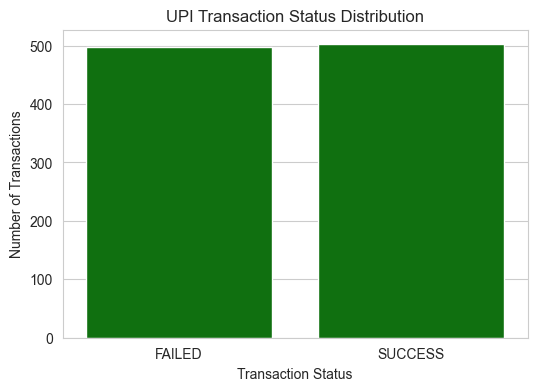

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Status', data=df, color='green')
plt.title('UPI Transaction Status Distribution')
plt.xlabel('Transaction Status')
plt.ylabel('Number of Transactions')
plt.savefig('../plots/status_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Transaction Amount Distribution

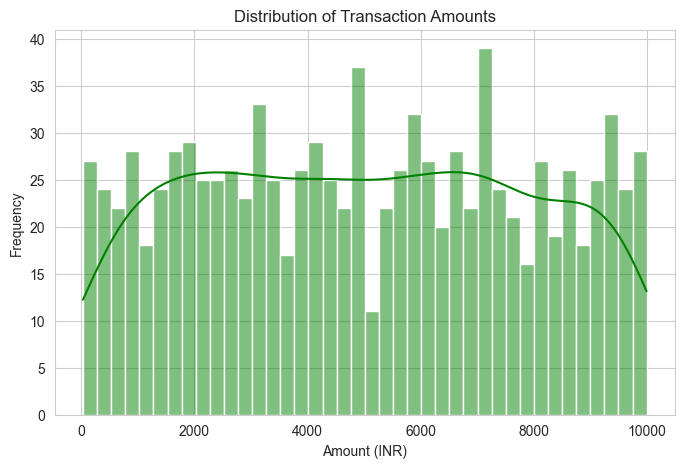

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount (INR)'], bins=40, kde=True, color='green')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount (INR)')
plt.ylabel('Frequency')
plt.savefig('../plots/amount_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Time Feature Engineering

In [10]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

## Transactions by Hour

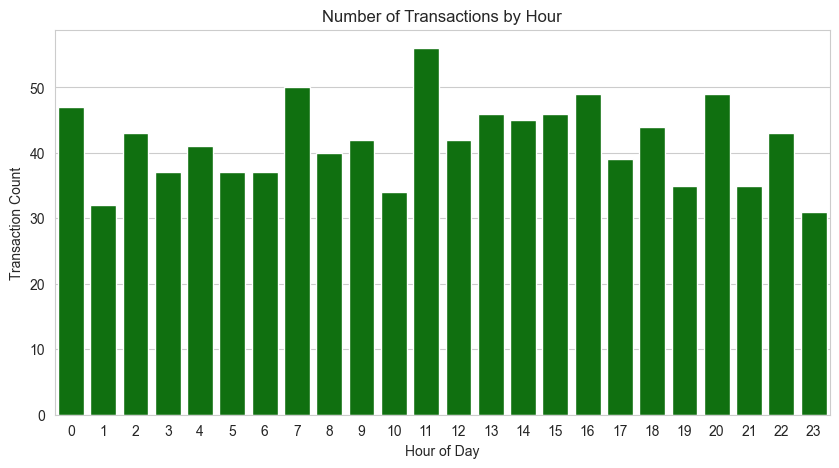

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=df, color='green')
plt.title('Number of Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Transaction Count')
plt.savefig('../plots/transactions_by_hour.png', dpi=300, bbox_inches='tight')
plt.show()

## Failure Rate by Hour

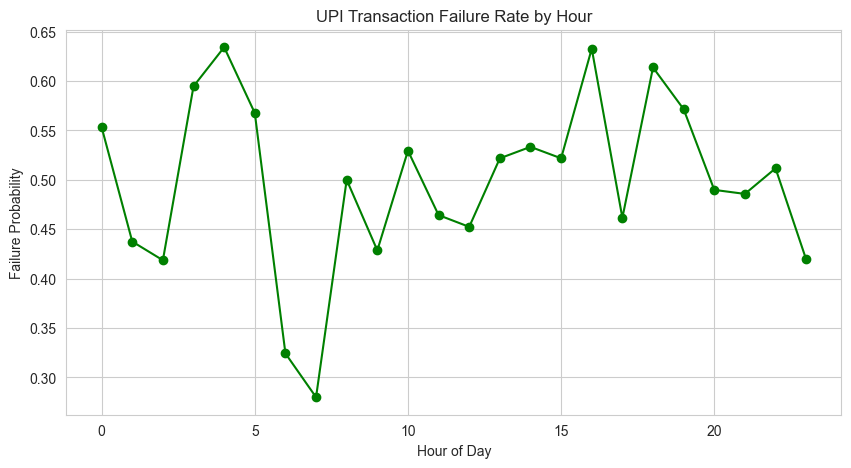

In [12]:
failure_rate = df.groupby('Hour')['Status'].apply(lambda x: (x=='FAILED').mean())
plt.figure(figsize=(10,5))
failure_rate.plot(color='green', marker='o')
plt.title('UPI Transaction Failure Rate by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Failure Probability')
plt.savefig('../plots/failure_rate_hour.png', dpi=300, bbox_inches='tight')
plt.show()

## Extract Bank Identifiers

In [13]:
df['Sender_Bank'] = df['Sender UPI ID'].apply(lambda x: x.split('@')[1])
df['Receiver_Bank'] = df['Receiver UPI ID'].apply(lambda x: x.split('@')[1])

## Sender Bank Distribution

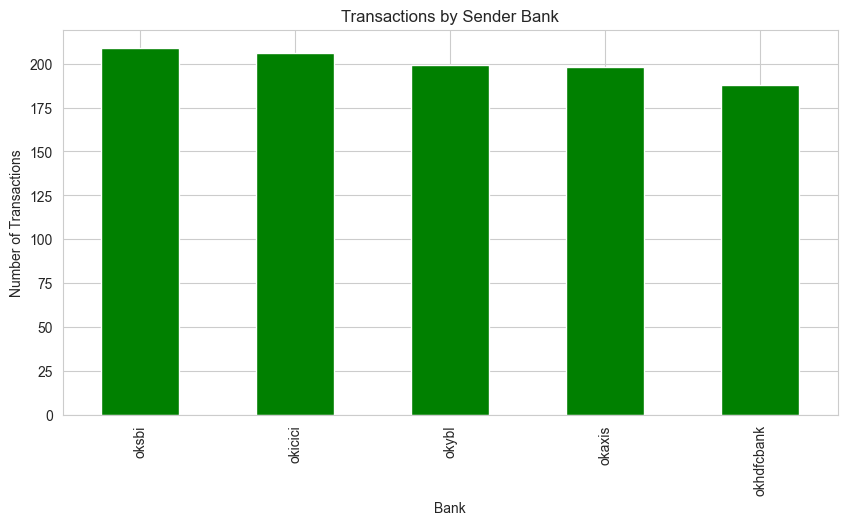

In [14]:
plt.figure(figsize=(10,5))
df['Sender_Bank'].value_counts().plot(kind='bar', color='green')
plt.title('Transactions by Sender Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Transactions')
plt.savefig('../plots/sender_bank_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Receiver Bank Distribution

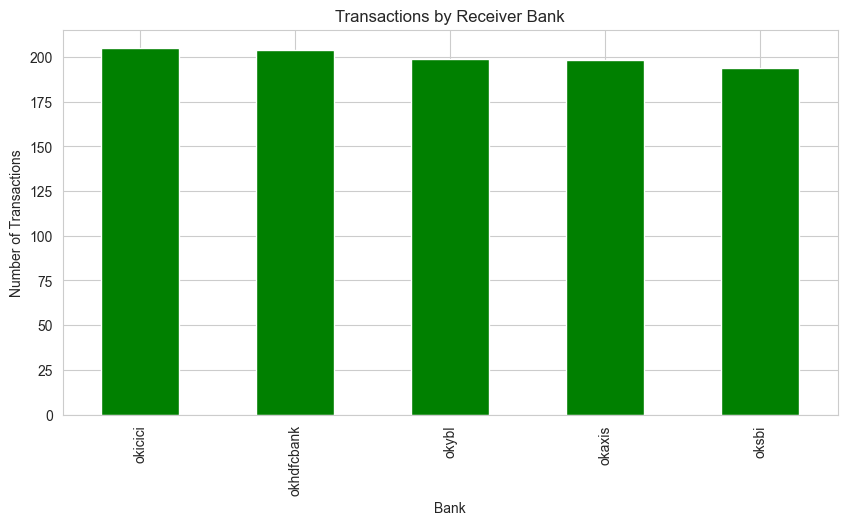

In [15]:
plt.figure(figsize=(10,5))
df['Receiver_Bank'].value_counts().plot(kind='bar', color='green')
plt.title('Transactions by Receiver Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Transactions')
plt.savefig('../plots/receiver_bank_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Transaction Amount vs Status

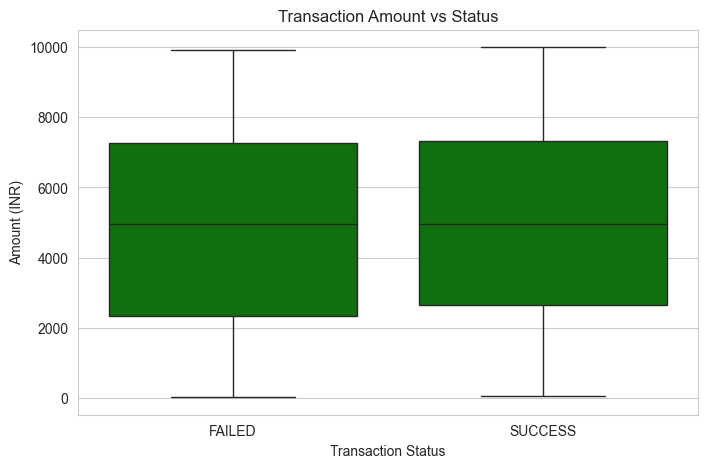

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Status', y='Amount (INR)', data=df, color='green')
plt.title('Transaction Amount vs Status')
plt.xlabel('Transaction Status')
plt.ylabel('Amount (INR)')
plt.savefig('../plots/amount_vs_status.png', dpi=300, bbox_inches='tight')
plt.show()

## Correlation Heatmap

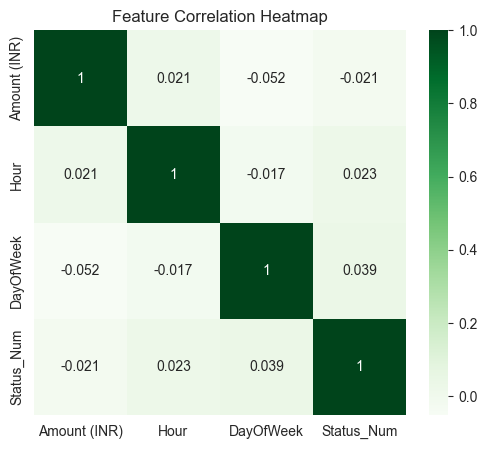

In [17]:
df['Status_Num'] = df['Status'].map({'SUCCESS':0,'FAILED':1})
plt.figure(figsize=(6,5))
sns.heatmap(df[['Amount (INR)','Hour','DayOfWeek','Status_Num']].corr(), annot=True, cmap='Greens')
plt.title('Feature Correlation Heatmap')
plt.savefig('../plots/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()